In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 윈도우 맑은 고딕 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [2]:
base_path = r"C:\kdt_0900_osh\data_analysis\resource\dataset"
file_name = r"hr_employee_attrition.csv"

file_path = os.path.join(base_path,file_name)
hr_df = pd.read_csv(file_path)
hr_df

,Attrition,Age,Gender,MaritalStatus,Education,Department,JobRole,BusinessTravel,OverTime,DistanceFromHome,MonthlyIncome,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,YearsAtCompany,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,PerformanceRating,YearsSinceLastPromotion
0,Yes,41,Female,Single,2,Sales,Sales Executive,Travel_Rarely,Yes,1,5993,11,0,8,6,2,4,1,3,0
1,No,49,Male,Married,1,Research & Development,Research Scientist,Travel_Frequently,No,8,5130,23,1,10,10,3,2,3,4,1
2,Yes,37,Male,Single,2,Research & Development,Laboratory Technician,Travel_Rarely,Yes,2,2090,15,0,7,0,4,3,3,3,0
3,No,33,Female,Married,4,Research & Development,Research Scientist,Travel_Frequently,Yes,3,2909,11,0,8,8,4,3,3,3,3
4,No,27,Male,Married,1,Research & Development,Laboratory Technician,Travel_Rarely,No,2,3468,12,1,6,2,1,2,3,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,No,36,Male,Married,2,Research & Development,Laboratory Technician,Travel_Frequently,No,23,2571,17,1,17,5,3,4,3,3,0
1466,No,39,Male,Married,1,Research & Development,Healthcare Representative,Travel_Rarely,No,6,9991,15,1,9,7,4,1,3,3,1
1467,No,27,Male,Married,3,Research & Development,Manufacturing Director,Travel_Rarely,Yes,4,6142,20,1,6,6,2,2,3,4,0
1468,No,49,Male,Married,3,Sales,Sales Executive,Travel_Frequently,No,2,5390,14,0,17,9,4,2,2,3,0


### 1. 야근(OverTime)을 하는 직원과 하지 않는 직원의 이직(Attrition) 비율은 얼마나 차이가 나는지 그래프로 나타내고 분석 결과를 서술하세요.

In [3]:
hr_df.groupby("OverTime")["Attrition"].agg(
    att_yes = lambda x: (x == "Yes").sum(),
    att_no = lambda x: (x == "No").sum()
)

,att_yes,att_no
OverTime,,
No,110,944
Yes,127,289


In [4]:
overtime_attrition = hr_df.groupby("OverTime")["Attrition"].agg(
    att_yes = lambda x: (x == "Yes").mean(),
    att_no = lambda x: (x == "No").mean()
) * 100
overtime_attrition

,att_yes,att_no
OverTime,,
No,10.436433,89.563567
Yes,30.528846,69.471154


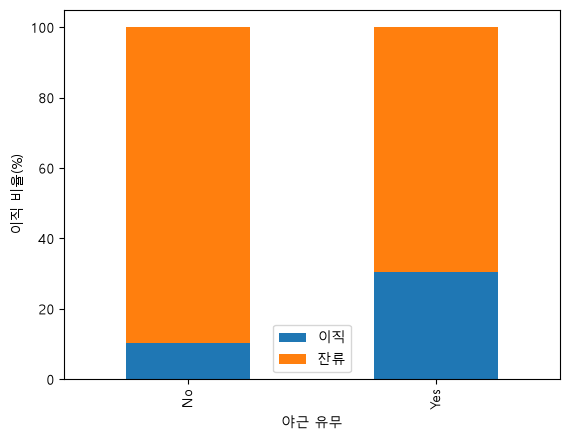

In [5]:
overtime_attrition.plot(kind="bar",stacked=True)
plt.xlabel("야근 유무")
plt.ylabel("이직 비율(%)")
plt.legend(["이직","잔류"])
plt.show()

분석 결과: 
1. 야간 근무를 하지 않는 사람의 이직비율은 약 10%, 야간 근무를 하는 사람의 이직비율은 약 30%이다.
2. 야간 근무를 하는 사람의 이직비율이 하지 않는 사람의 이직비율보다 약 3배 가량 높다.

결론: 야간 근무를 하는 사람이 야간 근무를 하지 않는 사람보다 이직할 확률이 높음을 알 수 있다.

### 2. 이직한 직원(Yes)과 잔류한 직원(No)의 월소득(MonthlyIncome) 평균 및 분포(Boxplot)에는 어떤 차이가 있는지 결과를 분석하고 그래프로 나타내고 서술하세요,

In [6]:
hr_df.groupby("Attrition")["MonthlyIncome"].mean().to_frame()
# 이직한 직원의 평균 월소득: 약 4787달러
# 잔류한 직원의 평균 월소득: 약 6832달러

,MonthlyIncome
Attrition,
No,6832.739659
Yes,4787.092827


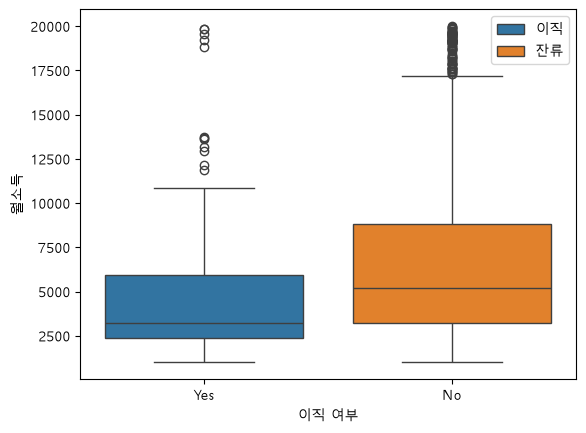

In [9]:
sns.boxplot(data=hr_df,x="Attrition",y="MonthlyIncome",hue="Attrition")
plt.xlabel("이직 여부")
plt.ylabel("월소득")
plt.legend(["이직", "잔류"])
plt.show()

분석결과: 
1. 이직한 직원의 평균 월소득은 약 4787 달러로, 잔류한 직원의 평균 월소득인 약 6832 달러보다 2000 달러 가량 낮았다.
2. 이직한 직원의 중위값 또한 3000 달러 근처에 형성되어 있으며, 잔류한 직원의 중위값 약 5000 달러보다 2000 달러 가량 낮았다.
3. boxplot에서 이직한 직원의 중위값 위치가 1분위값 방향으로 치우쳐있는 것으로 보아 중위값 이하의 월소득을 가진 직원들이 중위값 이상의 월소득을 가진 직원보다 훨씬 많음을 알 수 있다.
4. 최대이상치를 초과하는 값들이 존재하나 그 개수가 여러 개이고 비교적 고르게 분포해 있으며 충분히 나올 수 있는 월소득이라 판단하여 이들을 이상치로 보지 않았다.

결론: 이직한 직원의 월소득은 잔류한 직원의 월소득에 비해 전체적으로 낮음을 알 수 있다.

### 3. 마지막 승진 후 기간(YearsSinceLastPromotion)이 길어질수록 이직률이 높아진다는 가설이 맞는지 결과를 분석하고 그래프로 나타내고 서술하세요,

In [10]:
hr_df.groupby("YearsSinceLastPromotion")["Attrition"].count()

YearsSinceLastPromotion
0     581
1     357
2     159
3      52
4      61
5      45
6      32
7      76
8      18
9      17
10      6
11     24
12     10
13     10
14      9
15     13
Name: Attrition, dtype: int64

In [11]:
lastpro_attrition = pd.crosstab(hr_df["YearsSinceLastPromotion"], hr_df["Attrition"], normalize="index") * 100
lastpro_attrition
# 마지막 승진 후 기간별 이직률

Attrition,No,Yes
YearsSinceLastPromotion,,
0,81.067126,18.932874
1,86.274510,13.725490
2,83.018868,16.981132
3,82.692308,17.307692
4,91.803279,8.196721
5,95.555556,4.444444
6,81.250000,18.750000
7,78.947368,21.052632
8,100.000000,0.000000


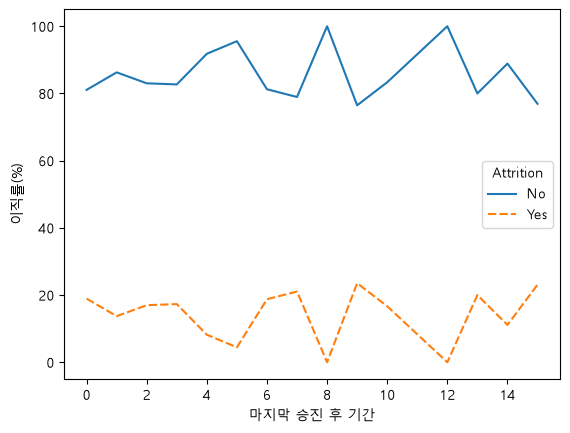

In [19]:
sns.lineplot(lastpro_attrition)
plt.xlabel("마지막 승진 후 기간")
plt.ylabel("이직률(%)")
plt.show()

분석결과: 
1. 마지막 승진 후 기간이 0 ~ 3년 사이, 6 ~ 7년 사이, 9년, 13년, 15년인 경우의 이직률이 높게 나타난다.
2. 4 ~ 5년 사이, 8년, 12년, 14년인 경우에는 이전보다 이직률이 낮아지는 경향을 보인다.
3. 8,9,10,12,13,14,15년의 표본 수가 부족하여 해당 기간의 신뢰성은 낮을 수 있다.
4. 가설이 사실이 되려면 그래프의 선이 우상향하는 형태를 띄고 있어야 한다.
5. 실제 그래프의 선은 불규칙하게 물결치는 모양을 띄고 있다.  

결론 : 위 정보를 종합해보면 가설을 채택하기에는 무리가 있다.

### 4. 워라밸 만족도(WorkLifeBalance: 1~4점) 점수별 이직률을 구하고, 워라밸이 낮을 때(1점)의 이직 위험도를 분석하고 그래프로 나타내고 서술하세요,

In [20]:
hr_df.groupby("WorkLifeBalance")["Attrition"].apply(lambda x: x.count())

WorkLifeBalance
1     80
2    344
3    893
4    153
Name: Attrition, dtype: int64

In [21]:
wlb_attrition = hr_df.groupby("WorkLifeBalance")["Attrition"].apply(lambda x: (x == "Yes").mean()).to_frame() * 100
wlb_attrition
# 워라밸 만족도 점수별 이직률
# 1점의 이직률이 2,3,4점 이직률보다 높음.

,Attrition
WorkLifeBalance,
1,31.250000
2,16.860465
3,14.221725
4,17.647059


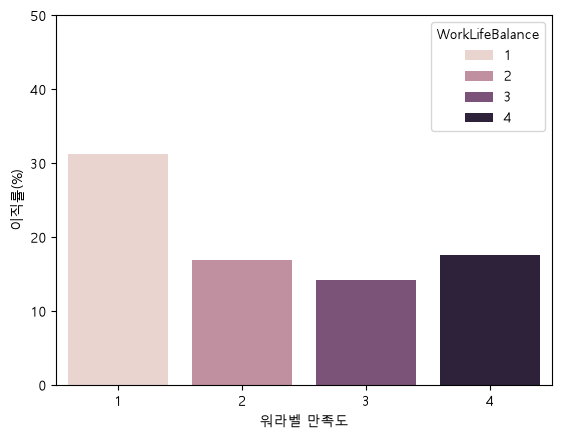

In [25]:
sns.barplot(data=wlb_attrition, x="WorkLifeBalance", y="Attrition", hue="WorkLifeBalance")
plt.ylim(0,50)
plt.xlabel("워라벨 만족도")
plt.ylabel("이직률(%)")
plt.show()

분석 결과:
1. 워라벨 만족도가 1점인 경우의 이직률이 30%로 가장 높게 나타났다.
2. 워라벨 만족도 2,3,4점인 경우의 이직률은 14~17% 정도로, 만족도 1점의 이직률과 비교하여 절반 수준의 이직률을 보인다.
3. 워라벨 만족도 4점의 경우에는 3점인 경우의 이직률보다 더 높게 나타났다. 다만 그렇다해도 워라벨 만족도 1점과 비교하면 상대적으로 낮은 이직률을 보여준다.

결론 : 워라벨 만족도 1점인 경우의 이직 위험도는 2,3,4점인 경우보다 2배가량 높다.